In [2]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load data 
df = pd.read_csv('/home/susan/mof-co2-adsorption/data/raw/hmof_full_structural_co2.csv')
data = df.copy()
print(data .info())
print()
print('='*30)
print(data.shape)
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32768 entries, 0 to 32767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   filename                  32768 non-null  object 
 1   lcd                       32768 non-null  float64
 2   pld                       32768 non-null  float64
 3   void_fraction             32768 non-null  float64
 4   surface_area_m2g          32768 non-null  float64
 5   mofid                     29063 non-null  object 
 6   CO2_uptake_0.01bar_molkg  32768 non-null  float64
 7   CO2_uptake_0.05bar_molkg  32768 non-null  float64
 8   CO2_uptake_0.1bar_molkg   32768 non-null  float64
 9   CO2_uptake_0.5bar_molkg   32768 non-null  float64
 10  CO2_uptake_2.5bar_molkg   32768 non-null  float64
dtypes: float64(9), object(2)
memory usage: 2.8+ MB
None

(32768, 11)



In [19]:
# column correction 
data.columns = (
    data.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.lower()
    .str.replace('co2', 'CO2', regex=False)
)
print(data.columns)
print()
print('='*30)
# check for missing and duplicated data 
missing_data = data.isna().sum()
missing_data = missing_data[missing_data > 0]

print('Missing values by column:')
print(missing_data)
print()
print('='*30)
# After missing value, inspect which rows are missing in the mofid column
print(data[data['mofid'].isna()].head())
print()
print('='*30)
# Check for duplicated data 
duplicate_data = data.duplicated().sum()
print(f'number of duplicated : {duplicate_data}')
print()
print('='*30)
# Interpretation of the cleaning output
print('''
Interpretation:
- The dataset contains 32,768 rows and 11 columns.
- The only missing value column identified is mofid, with 3,705 missing entries.
- The missing mofid rows appear in the early part of the dataset and are valid to inspect further.
- No duplicate rows were found, so no deduplication is needed.
''')

Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='str')

Missing values by column:
mofid    3528
dtype: int64

      filename    lcd    pld  void_fraction  surface_area_m2g mofid  \
9   hMOF-10005   8.75   7.75       0.733001            2954.6   NaN   
10  hMOF-10006  10.75   9.25       0.733034            2468.9   NaN   
11  hMOF-10007  12.25  11.25       0.821194            4204.3   NaN   
12  hMOF-10008   6.25   2.75       0.530844            1101.4   NaN   
13  hMOF-10009   4.25   3.75       0.309850             252.2   NaN   

    CO2_uptake_0.01bar_molkg  CO2_uptake_0.05bar_molkg  \
9                   0.091681                  0.266074   
10                  0.053527                  0.271804   
11                  0.032862                  0.111283   
12                  0.219827 

In [ ]:
missing_id = (
    df["mofid"].isna()
    | df["mofid"].astype("string").str.strip().str.lower().isin(["", "none", "nan"])
)
zero_area = df["surface_area_m2g"].eq(0)

suspect_rows = df.loc[missing_id & zero_area].copy()

print("Missing MOFid:", missing_id.sum())
print("Zero surface area:", zero_area.sum())
print("Either problem:", (missing_id & zero_area).sum())

suspect_rows.to_csv("suspect_mof_rows.csv", index=False)

Missing MOFid: 3705
Zero surface area: 1534
Either problem: 177


In [8]:
# Identify rows where the MOFid is missing or stored as an invalid text value.
missing_id = df["mofid"].isna() | df["mofid"].astype("string").str.strip().str.lower().isin(["", "none", "nan"])

# Identify rows where the surface area is exactly zero.
zero_area = df["surface_area_m2g"].eq(0)

# Identify rows that have both a missing MOFid and zero surface area.
both_problems = missing_id & zero_area

# Select the rows with both problems for investigation before deletion.
rows_to_check = df.loc[both_problems].copy()

# Add the original DataFrame index so the rows can be traced back later.
rows_to_check.insert(0, "original_index", rows_to_check.index)

# Print the number of rows that have both problems.
print("Rows with both problems:", both_problems.sum())

# Display the first ten rows that have both problems.
display(rows_to_check.head(10))

# Save the 177 rows as an audit file before making any deletion.
rows_to_check.to_csv("rows_with_both_problems.csv", index=False)

Rows with both problems: 177


,original_index,filename,lcd,pld,void_fraction,surface_area_m2g,mofid,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
11497,11497,hMOF-20423,2.75,1.75,5.202770e-02,0.0,NaN,0.092878,0.361435,0.424960,0.694219,0.700965
11517,11517,hMOF-20441,2.75,1.25,1.507860e-02,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11522,11522,hMOF-20446,2.75,2.25,8.868290e-02,0.0,NaN,0.113150,0.165707,0.237439,0.255881,0.300201
11573,11573,hMOF-20492,1.75,1.25,3.280000e-06,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11576,11576,hMOF-20495,2.25,2.25,6.260000e-05,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11578,11578,hMOF-20497,2.25,1.25,8.270000e-05,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11583,11583,hMOF-20500,1.75,1.25,2.250000e-07,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11585,11585,hMOF-20502,2.25,1.75,9.230000e-05,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11587,11587,hMOF-20504,1.75,1.25,4.950000e-06,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
11589,11589,hMOF-20506,1.75,1.25,5.740000e-05,0.0,NaN,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
# Find the indexes of rows where the surface area equals zero.
zero_area_indexes = data[data["surface_area_m2g"].eq(0)].index

# Remove the rows with zero surface area from the original DataFrame.
data.drop(index=zero_area_indexes, inplace=True)

# Reset the index after removing the rows.
data.reset_index(drop=True, inplace=True)

# Confirm that no zero-surface-area rows remain.
print("Zero surface-area rows remaining:", data["surface_area_m2g"].eq(0).sum())

# Display the new shape of the cleaned DataFrame.
print("Cleaned data shape:", data.shape)

Zero surface-area rows remaining: 0
Cleaned data shape: (31234, 11)


In [22]:
# clean copy data a save it :
data_cleaned = data.copy()
print(data_cleaned.info())
data_cleaned.to_csv('data_clean_v2',index= False)

<class 'pandas.DataFrame'>
RangeIndex: 31234 entries, 0 to 31233
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   filename                  31234 non-null  str    
 1   lcd                       31234 non-null  float64
 2   pld                       31234 non-null  float64
 3   void_fraction             31234 non-null  float64
 4   surface_area_m2g          31234 non-null  float64
 5   mofid                     27706 non-null  str    
 6   CO2_uptake_0.01bar_molkg  31234 non-null  float64
 7   CO2_uptake_0.05bar_molkg  31234 non-null  float64
 8   CO2_uptake_0.1bar_molkg   31234 non-null  float64
 9   CO2_uptake_0.5bar_molkg   31234 non-null  float64
 10  CO2_uptake_2.5bar_molkg   31234 non-null  float64
dtypes: float64(9), str(2)
memory usage: 2.6 MB
None


In [15]:
# Checking the clean data 

print(data_cleaned.shape)
print()
print('='*30)
print(data_cleaned.columns)
print()
print('='*30)
data_cleaned.head(5)

(31234, 11)

Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='str')



,filename,lcd,pld,void_fraction,surface_area_m2g,mofid,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
0,hMOF-0,11.75,10.75,0.795539,3676.3,[O-]C(=O)c1ccc(cc1)C(=O)[O-].[Zn][O]([Zn])([Zn...,0.022406,0.073552,0.225851,0.885221,4.33307
1,hMOF-1,4.75,3.25,0.388986,580.7,[O-]C(=O)c1ccc(cc1)C(=O)[O-].[Zn][O]([Zn])([Zn...,0.173407,0.925813,1.806490,4.779010,7.34618
2,hMOF-10,4.75,3.75,0.307505,377.6,[O-]C(=O)c1cc(F)c(c(c1F)F)C(=O)[O-].[Zn][O]([Z...,0.651164,2.129830,2.817220,3.909470,4.93236
3,hMOF-100,9.25,8.25,0.731919,3399.2,COc1cc(cc(c1C(=O)[O-])OC)C(=O)[O-].COc1cc(ccc1...,0.031321,0.143123,0.332034,1.756380,6.91190
4,hMOF-1000,3.75,2.75,0.323803,85.2,CCc1cc(C(=O)[O-])c(c(c1C(=O)[O-])CC)CC.[O-]C(=...,0.144024,0.698367,1.402230,2.694200,4.15694


## Data Cleaning Summary

- Loaded the dataset and inspected its structure, including shape, columns, and sample records.
- Standardized column names by removing extra whitespace, converting them to lowercase, and replacing spaces with underscores.
- Identified and summarized missing values by column.
- Reviewed rows with missing mofid values to assess data quality.
- Checked for duplicate records and counted them.
- Investigated rows with zero surface area and removed those with both zero surface area and missing mofid.
- Rechecked the remaining missing values after filtering.
- Explored potential outliers using descriptive statistics, boxplots, and the IQR method for key numeric features.

### Next Step
- The remaining missing values should be handled carefully, for example by imputation, removal, or using a model that can handle them.

In [20]:
# Check for outliers in lcd, pld, void_fraction, surface_area_m2g
# Select numeric columns
numeric_cols = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g']

# Show basic stats
print(data_cleaned[numeric_cols].describe())

                lcd           pld  void_fraction  surface_area_m2g
count  31234.000000  31234.000000   31234.000000      31234.000000
mean       8.805164      7.298937       0.645685       2559.070702
std        3.641698      3.791966       0.173932       1497.801602
min        2.250000      1.250000       0.037893          0.100000
25%        6.250000      4.250000       0.547544       1331.625000
50%        7.750000      6.250000       0.681862       2529.300000
75%       10.750000      9.750000       0.780025       3710.000000
max       24.250000     21.750000       0.927693       6741.700000


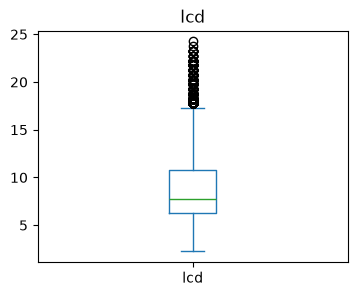

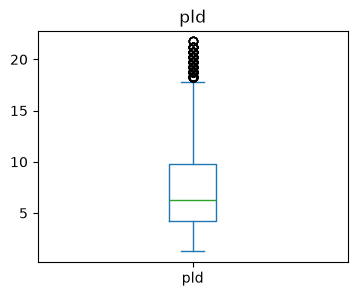

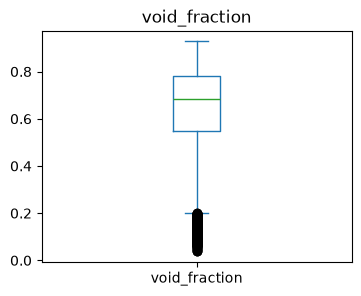

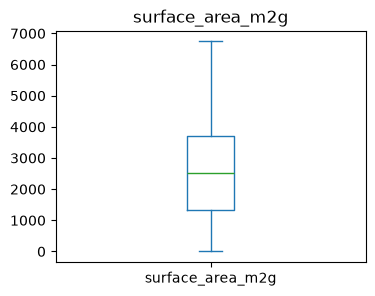

In [23]:
#  A simple way is to check numeric columns with summary statistics and boxplots.
# check for outliers with a boxplot:
for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    data[col].plot(kind='box')
    plt.title(col)
    plt.show()


======================================================
## 📊 Outlier Analysis — Boxplot Interpretation

### `void_fraction`
- **Median** ≈ 0.65 | **IQR** ≈ 0.55 – 0.78
- Lower outliers clustered near **0.0 – 0.2**
- Most MOFs are **highly porous**; a small subset has very low void fractions (dense structures)

---

### `pld` (Pore Limiting Diameter)
- **Median** ≈ 6 Å | **IQR** ≈ 4 – 10 Å
- Upper outliers above **~18 Å**
- Right-skewed — majority of MOFs have moderate pore openings

---

### `lcd` (Largest Cavity Diameter)
- **Median** ≈ 7 Å | **IQR** ≈ 5 – 10 Å
- Upper outliers above **~17 Å**
- Right-skewed — consistent with `pld` since `lcd` ≥ `pld` always

---

## 📝 Summary Table

| Column          | Median  | Outlier Direction | Notes                              |
|-----------------|---------|-------------------|------------------------------------|
| `void_fraction` | ~0.65   | Lower (< 0.2)     | Dense/defective MOFs               |
| `pld`           | ~6 Å    | Upper (> 18 Å)    | MOFs with very large pore openings |
| `lcd`           | ~7 Å    | Upper (> 17 Å)    | MOFs with very large cavities      |

> ✅ Outliers appear to be **physically valid structures**, not data errors.  
> ⚠️ Consider flagging extreme values for **sensitivity analysis** in CO₂ adsorption modeling.

In [27]:
# Detect outliers using the IQR rule:(standard method)
for col in numeric_cols:
    q1 = data_cleaned[col].quantile(0.25)
    q3 = data_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = data_cleaned[(data_cleaned[col] < lower) | (data_cleaned[col] > upper)]
    print(col, 'outliers:', len(outliers))
    print(outliers[[col, 'mofid']].head())

lcd outliers: 688
       lcd                                              mofid
380  19.25  [O-]C(=O)c1ccc(c2c1cccc2)C(=O)[O-].[O-]C(=O)c1...
382  18.25  FOC(=O)c1c(F)c(F)c(c2c1[C]=CC=C2F)C(=O)[O-].Fc...
384  18.25  Fc1c(ccc(c1F)C(=O)[O-])c1cc(F)c(c(c1)F)c1ccc(c...
388  17.75  Fc1cc(ccc1c1ccc(cc1)C(=O)[O-])c1c(F)c(F)c(c(c1...
391  18.25  Fc1cc(ccc1c1ccc(c(c1)F)C(=O)[O-])c1cc(F)c(c(c1...
pld outliers: 213
        pld                                              mofid
449   19.25  N#Cc1c(ccc(c1C#N)c1c(C#N)cc(c(c1C#N)C#N)C(=O)[...
770   19.25  Fc1cc(C(=O)[O-])c(cc1C#Cc1cc(F)c(c(c1F)F)C(=O)...
1714  21.75  Fc1c(ccc(c1F)c1cc(F)c(c(c1F)F)C(=O)[O-])c1ccc(...
2169  18.75  [O-]C(=O)c1ccc(cc1)N=Nc1ccc(cc1)C(=O)[O-].[Zn]...
3367  19.75  Fc1cc(C(=O)[O-])c(c(c1C#Cc1ccc(cc1)C(=O)[O-])F...
void_fraction outliers: 619
     void_fraction                                              mofid
5         0.194771  [O-]C(=O)c1cc(Br)c2c(c1)ccc(c2)C(=O)[O-].[O-]C...
37        0.090123  [O-]C(=O)C(=O)[O-].[O-]C(=

## 📊 IQR Outlier Detection — Interpretation

### `lcd` (Largest Cavity Diameter) — **688 outliers**
- Outliers have `lcd` values **above ~17 Å**
- These MOFs have unusually large internal cavities
- Likely **real open-framework structures** with wide pores
- Examples show complex aromatic linkers (fluorinated, CN-substituted) — consistent with large pore MOFs

---

### `pld` (Pore Limiting Diameter) — **213 outliers**
- Outliers have `pld` values **above ~18 Å**
- Fewer outliers than `lcd` — expected since `pld ≤ lcd` always
- These MOFs have very wide **accessible pore channels**
- Could be highly favorable for CO₂ diffusion but may show lower selectivity

---

### `void_fraction` — **619 outliers**
- Outliers have `void_fraction` values **below ~0.2**
- These are unusually **dense MOFs** with little empty space
- May have **low CO₂ adsorption capacity** due to limited pore volume
- Worth flagging — could behave differently in adsorption modeling

---

### `surface_area_m2g` — **0 outliers** ✅
- No outliers detected after removing zero-surface-area rows
- Surface area is **well-distributed** across the dataset
- No further action needed for this column

---

## 📝 Summary Table

| Column            | # Outliers | Direction | Action Recommended                        |
|-------------------|------------|-----------|-------------------------------------------|
| `lcd`             | 688        | Upper     | Keep — physically valid large-pore MOFs   |
| `pld`             | 213        | Upper     | Keep — wide accessible channels           |
| `void_fraction`   | 619        | Lower     | Flag — dense MOFs, low adsorption likely  |
| `surface_area_m2g`| 0          | —         | No action needed ✅                        |

> ✅ **No rows need to be removed** — all outliers represent physically valid MOF structures.  
> ⚠️ Consider **flagging** low `void_fraction` MOFs (< 0.2) as a separate group during CO₂ adsorption modeling.

## Boxplot and IQR Outlier Analysis

Two complementary approaches were used to examine unusual values in the four structural features: **boxplots** and the **numerical IQR rule**.

### Method Comparison

| Aspect        | Boxplot                                       | Numerical IQR Rule                                              |
| ------------- | --------------------------------------------- | --------------------------------------------------------------- |
| Purpose       | Visual exploration                            | Exact outlier identification                                    |
| Shows         | Median, spread, skewness, and extreme values  | Lower and upper boundaries                                      |
| Output        | Visual pattern                                | Thresholds, counts, and row indexes                             |
| Main strength | Easy to interpret distributions               | Objective and reproducible                                      |
| Limitation    | Exact values are difficult to obtain visually | Does not determine whether an outlier is scientifically invalid |
| Best use      | Understanding the data distribution           | Flagging records for further analysis                           |

A standard boxplot normally uses the same **1.5 × IQR rule**:

* **IQR** = Q3 − Q1
* **Lower boundary** = Q1 − 1.5 × IQR
* **Upper boundary** = Q3 + 1.5 × IQR

Therefore, boxplots and numerical IQR calculations are not completely independent methods. The boxplot visually presents the results, while the numerical calculation provides the exact boundaries and affected rows.

### Which Method Is More Reliable?

The numerical IQR method is more reliable for formally identifying outliers because it is objective, reproducible, and provides exact counts. The boxplot is more useful for understanding the direction of the outliers, skewness, and the overall shape of each distribution.

However, neither method determines whether an observation is a data error. Scientific plausibility and data-quality checks must be considered before removing any MOF records.

### Outlier Results

The analysis was performed after removing records with `surface_area_m2g == 0`. The cleaned dataset contains **31,234 MOFs**.

| Feature            | IQR Outliers | Direction | Interpretation                                          | Decision          |
| ------------------ | -----------: | --------- | ------------------------------------------------------- | ----------------- |
| `lcd`              |          688 | Upper     | MOFs with unusually large internal cavities             | Keep and flag     |
| `pld`              |          213 | Upper     | MOFs with unusually wide pore openings                  | Keep and flag     |
| `void_fraction`    |          619 | Lower     | Dense MOFs with relatively little accessible void space | Keep and flag     |
| `surface_area_m2g` |            0 | None      | No values fall outside the calculated IQR boundaries    | No outlier action |

The counts should not be added together because the same MOF may be an outlier in more than one feature.

### Final Outlier Decision

The extreme values may represent unusual but plausible hypothetical MOF structures. There is currently no evidence that they are data-entry or extraction errors. Therefore:

* The `lcd`, `pld`, and `void_fraction` outliers will be retained.
* Outlier records will be flagged rather than deleted.
* The main models will first be trained using all 31,234 cleaned records.
* Sensitivity analysis will later compare model results with and without the flagged records.
* Differences in model performance and feature importance will show whether the outliers materially influence the conclusions.

A result of zero IQR outliers for `surface_area_m2g` only means that no values exceed its calculated IQR boundaries. It does not, by itself, prove that the feature is normally or evenly distributed.

